# I. Data Preprocessing

## 1. Load dữ liệu

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, permutation_test


### 1.1. Đọc dữ liệu items

In [2]:
items_lf = pl.scan_parquet("../../raw_data/items.parquet")

items_lf.collect().schema

Schema([('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('category_l1', String),
        ('category_l2', String),
        ('category_l3', String),
        ('category', String),
        ('brand', String),
        ('manufacturer', String),
        ('description', String),
        ('sale_status', Int32),
        ('size', String)])

In [3]:
items_lf.head().collect()

item_id,price,category_l1,category_l2,category_l3,category,brand,manufacturer,description,sale_status,size
str,"decimal[38,4]",str,str,str,str,str,str,str,i32,str
"""0008040000046""",115000.0000,"""Đồ chơi & Sách""","""1Y+""","""Học tập và phát triển tư duy""","""Siêu nhân, robot""","""WinWinToys""","""Không xác định""","""Robo Luồn thun Winwintoys có h…",0,"""Không xác định"""
"""0502020000004""",99000.0000,"""Babycare""","""Bình sữa, phụ kiện""","""Núm ty""","""Núm ty Dr Brown""","""Dr.Brown's""","""Không xác định""","""Không xác định""",0,"""Không xác định"""
"""0007010000886""",102000.0000,"""Babycare""","""Bình sữa, phụ kiện""","""Núm ty""","""Núm ty Pigeon""","""Pigeon""","""Không xác định""","""Với hơn 60 năm qua, trải qua r…",0,"""Không xác định"""
"""0502020340030""",228000.0000,"""Babycare""","""Bình sữa, phụ kiện""","""Phụ kiện bình sữa""","""Bình, túi ủ sữa""","""KUKU""","""Không xác định""","""Bình ủ sữa của KuKu của Đài Lo…",0,"""Không xác định"""
"""0012050000007""",59000.0000,"""Thời trang""","""Cơ cấu hàng cũ""","""Đồ bầu""","""Áo ngực bầu""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Không xác định"""


### 1.2. Đọc dữ liệu transactions_202411-to-202412

In [4]:
trans24_lf = pl.scan_parquet("../../raw_data/transactions-202411-to-202412.parquet")

In [5]:
trans24_lf.collect().schema

Schema([('customer_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('channel', String),
        ('payment', String),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('location', Int32),
        ('quantity', Int32)])

In [6]:
trans24_lf.head().collect()

customer_id,item_id,price,channel,payment,updated_date,location,quantity
i32,str,"decimal[38,4]",str,str,datetime[μs],i32,i32
6680595,"""6033000000053""",169000.0000,"""In-Store""","""VietQR""",2024-12-29 17:37:10.410,181,1
3256247,"""4562000000101""",169000.0000,"""In-Store""","""VietQR""",2024-12-30 18:34:51.117,79,1
8180719,"""3500000000005""",49000.0000,"""In-Store""","""VietQR""",2024-12-22 16:01:47.987,1002,1
2079076,"""3500000000004""",49000.0000,"""In-Store""","""VietQR""",2024-12-16 18:30:58.480,242,1
7311623,"""3460000000009""",49500.0000,"""In-Store""","""VietQR""",2024-12-14 19:41:23.670,972,1


### 1.3. Đọc dữ liệu transactions_2025-12

In [7]:
trans25_lf = pl.scan_parquet("../../raw_data/transactions-2025-12.parquet")

In [8]:
trans25_lf.collect().schema


Schema([('customer_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('channel', String),
        ('payment', String),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('location', Int32),
        ('quantity', Int32)])

In [9]:
trans25_lf.head().collect()

customer_id,item_id,price,channel,payment,updated_date,location,quantity
i32,str,"decimal[38,4]",str,str,datetime[μs],i32,i32
8861340,"""0151000000003""",1625000.0000,"""In-Store""","""Tiền mặt""",2025-12-12 16:44:47.793,385,1
8680587,"""5074000000001""",139000.0000,"""SPE""","""Tiền mặt""",2025-12-01 10:28:50.830,1063,1
8220170,"""5856000000001""",480000.0000,"""SPE""","""Tiền mặt""",2025-12-23 09:20:27.653,416,1
7496264,"""6768000000002""",316200.0000,"""SPE""","""Tiền mặt""",2025-12-23 09:06:39.980,336,3
9170522,"""6904000000002""",840000.0000,"""SPE""","""Không xác định""",2025-12-23 09:24:55.640,601,1


## 2. Gộp dữ liệu giao dịch

In [10]:
transactions_lf = pl.concat([
    trans24_lf,
    trans25_lf
])

print(transactions_lf.select(pl.len()).collect().item())

9835894


## 3. Join với bảng sản phẩm
- Đổi tên cột price trong bảng items.
    - transactions.price: giá tại thời điểm giao dịch
    - items.price: giá niêm yết sản phẩm

In [11]:
items_lf = items_lf.rename({
    "price": "item_price"
})

df_lf = transactions_lf.join(
    items_lf,
    on="item_id",
    how="left"
)

df_lf.collect().schema


Schema([('customer_id', Int32),
        ('item_id', String),
        ('price', Decimal(precision=38, scale=4)),
        ('channel', String),
        ('payment', String),
        ('updated_date', Datetime(time_unit='us', time_zone=None)),
        ('location', Int32),
        ('quantity', Int32),
        ('item_price', Decimal(precision=38, scale=4)),
        ('category_l1', String),
        ('category_l2', String),
        ('category_l3', String),
        ('category', String),
        ('brand', String),
        ('manufacturer', String),
        ('description', String),
        ('sale_status', Int32),
        ('size', String)])

#### - Loại bỏ các cột:
- customer_id, channel, payment, location, branch, manufacturer, description, size

In [12]:
df_lf = df_lf.select([
    "item_id",
    "price",
    "item_price",
    "quantity",
    "updated_date",
    "category_l1",
    "category_l2",
    "category_l3",
    "category",
    "sale_status"
])

df_lf.head().collect()

item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32
"""6033000000053""",169000.0000,219000.0000,1,2024-12-29 17:37:10.410,"""Thời trang""","""Thời trang bé gái""","""Bộ bé gái""","""Bộ bé gái Animo""",0
"""4562000000101""",169000.0000,199000.0000,1,2024-12-30 18:34:51.117,"""Thời trang""","""Thời trang bé gái""","""Bodysuit bé gái""","""Bodysuit bé gái đùi""",0
"""3500000000005""",49000.0000,79000.0000,1,2024-12-22 16:01:47.987,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3500000000004""",49000.0000,79000.0000,1,2024-12-16 18:30:58.480,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1


## 4. Phát hiện và xử lý Missing Data

In [13]:
# các dòng thiếu dữ liệu quan trọng sẽ bị loại bỏ
df_lf = df_lf.filter(
    pl.col("item_id").is_not_null() &
    pl.col("price").is_not_null() &
    pl.col("quantity").is_not_null() &
    pl.col("updated_date").is_not_null()
)
df_lf.head().collect()


item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32
"""6033000000053""",169000.0000,219000.0000,1,2024-12-29 17:37:10.410,"""Thời trang""","""Thời trang bé gái""","""Bộ bé gái""","""Bộ bé gái Animo""",0
"""4562000000101""",169000.0000,199000.0000,1,2024-12-30 18:34:51.117,"""Thời trang""","""Thời trang bé gái""","""Bodysuit bé gái""","""Bodysuit bé gái đùi""",0
"""3500000000005""",49000.0000,79000.0000,1,2024-12-22 16:01:47.987,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3500000000004""",49000.0000,79000.0000,1,2024-12-16 18:30:58.480,"""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Phụ kiện cho bé""","""Set 2 đôi vớ""",0
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1


## 5. Lọc sản phẩm không còn bán

In [14]:
df_lf = df_lf.filter(
    pl.col("sale_status") == 1
)
print(df_lf.select(pl.len()).collect().item())



7933245


## 6. Loại bỏ dữ liệu bất thường

In [15]:
df_lf = df_lf.filter(
    (pl.col("price") > 0) &
    (pl.col("quantity") > 0)
)
print(df_lf.select(pl.len()).collect().item())


7933245


## 7. Phát hiện Outlier

In [16]:
stats = df_lf.select([
    pl.col("quantity").quantile(0.25).alias("q1"),
    pl.col("quantity").quantile(0.75).alias("q3")
]).collect()

q1 = stats["q1"][0]
q3 = stats["q3"][0]

iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

In [17]:
# Lọc Outlier
df_lf = df_lf.filter(
    (pl.col("quantity") >= lower) &
    (pl.col("quantity") <= upper)
)
print(df_lf.select(pl.len()).collect().item())

6361424


## 8. Feature Engineering

### 8.1. Tạo revenue: 
Ý nghĩa: Doanh thu của từng giao dịch.

Cách tính
$$revenue = price \times quantity$$

Mục đích
- Đo lường **giá trị doanh thu thực tế** của từng giao dịch.
- Cho phép tính **tổng doanh thu theo ngày** hoặc theo nhóm sản phẩm.

In [18]:
df_lf = df_lf.with_columns(
    (pl.col("price") * pl.col("quantity")).alias("revenue")
)

### 8.2. Tạo date
Ý nghĩa:
- Ngày giao dịch được trích xuất từ cột updated_date.

Mục đích:

- Chuyển dữ liệu từ timestamp (datetime) sang ngày.
- Cho phép aggregate dữ liệu theo ngày.
- Là biến chính để phân tích time-series doanh số.

In [19]:
df_lf = df_lf.with_columns(
    pl.col("updated_date").dt.date().alias("date")
)
df_lf.head().collect()

item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status,revenue,date
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32,"decimal[38,4]",date
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1,49500.0000,2024-12-14
"""4895000000001""",66000.0000,68000.0000,1,2024-12-30 09:03:10.533,"""Thực phẩm cho bé""","""TP từ sữa (bảo quản lạnh)""","""Váng sữa""","""Zott""",1,66000.0000,2024-12-30
"""0020010000210""",33950.0000,36000.0000,1,2024-12-28 18:37:03.107,"""Vệ sinh""","""Băng vệ sinh""","""Băng vệ sinh sau sinh""","""Băng vệ sinh Diana sau sinh""",1,33950.0000,2024-12-28
"""5420000000003""",29000.0000,29000.0000,1,2024-12-25 16:06:13.813,"""Thực phẩm cho bé""","""Cháo ăn dặm""","""Cháo tươi""","""Cây Thị""",1,29000.0000,2024-12-25
"""2406000000005""",585000.0000,635000.0000,1,2024-12-29 08:54:36.970,"""Sữa""","""Enfa""","""Enfa""","""Enfa Step 2""",1,585000.0000,2024-12-29


### 8.3. Tạo holiday feature
- Xác định ngày lễ:
    - 1: ngày lễ (ngày 24/12)
    - 0: ngày thường

In [20]:
df_lf = df_lf.with_columns(
    pl.when(
        (pl.col("date").dt.month() == 12) &
        (pl.col("date").dt.day() == 24)
    )
    .then(1)
    .otherwise(0)
    .alias("is_holiday")
)
df_lf.head().collect()


item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status,revenue,date,is_holiday
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32,"decimal[38,4]",date,i32
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1,49500.0000,2024-12-14,0
"""4895000000001""",66000.0000,68000.0000,1,2024-12-30 09:03:10.533,"""Thực phẩm cho bé""","""TP từ sữa (bảo quản lạnh)""","""Váng sữa""","""Zott""",1,66000.0000,2024-12-30,0
"""0020010000210""",33950.0000,36000.0000,1,2024-12-28 18:37:03.107,"""Vệ sinh""","""Băng vệ sinh""","""Băng vệ sinh sau sinh""","""Băng vệ sinh Diana sau sinh""",1,33950.0000,2024-12-28,0
"""5420000000003""",29000.0000,29000.0000,1,2024-12-25 16:06:13.813,"""Thực phẩm cho bé""","""Cháo ăn dặm""","""Cháo tươi""","""Cây Thị""",1,29000.0000,2024-12-25,0
"""2406000000005""",585000.0000,635000.0000,1,2024-12-29 08:54:36.970,"""Sữa""","""Enfa""","""Enfa""","""Enfa Step 2""",1,585000.0000,2024-12-29,0


### 8.4. Tạo weekday feature
- Ý nghĩa: weekday biểu diễn thứ trong tuần của ngày giao dịch
- Doanh số thường phụ thuộc vào ngày trong tuần (ví dụ khách hàng thường mua nhiều vào cuối tuần), giúp để kiểm soát là do holiday nó tăng doanh số hay là weekend (ngày cuối tuần) mới là nguyên nhân gây tăng doanh số. Do đó, mục đích:
    - Kiểm tra hiệu ứng ngày trong tuần
    - Tránh nhầm lẫn giữa holiday effect và weekend effect
- Phương thức .dt.weekday() trả về một số nguyên đại diện cho các ngày trong tuần với quy ước:

    - 1: Thứ Hai (Monday)

    - 2: Thứ Ba (Tuesday)

    - 3: Thứ Tư (Wednesday)

    - 4: Thứ Năm (Thursday)

    - 5: Thứ Sáu (Friday)

    - 6: Thứ Bảy (Saturday)

    - 7: Chủ Nhật (Sunday)

In [21]:
df_lf = df_lf.with_columns(
    pl.col("date").dt.weekday().alias("weekday")
)

df_lf.head().collect()

item_id,price,item_price,quantity,updated_date,category_l1,category_l2,category_l3,category,sale_status,revenue,date,is_holiday,weekday
str,"decimal[38,4]","decimal[38,4]",i32,datetime[μs],str,str,str,str,i32,"decimal[38,4]",date,i32,i8
"""3460000000009""",49500.0000,129000.0000,1,2024-12-14 19:41:23.670,"""Thời trang""","""Thời trang bé trai""","""Quần bé trai""","""Quần short bé trai""",1,49500.0000,2024-12-14,0,6
"""4895000000001""",66000.0000,68000.0000,1,2024-12-30 09:03:10.533,"""Thực phẩm cho bé""","""TP từ sữa (bảo quản lạnh)""","""Váng sữa""","""Zott""",1,66000.0000,2024-12-30,0,1
"""0020010000210""",33950.0000,36000.0000,1,2024-12-28 18:37:03.107,"""Vệ sinh""","""Băng vệ sinh""","""Băng vệ sinh sau sinh""","""Băng vệ sinh Diana sau sinh""",1,33950.0000,2024-12-28,0,6
"""5420000000003""",29000.0000,29000.0000,1,2024-12-25 16:06:13.813,"""Thực phẩm cho bé""","""Cháo ăn dặm""","""Cháo tươi""","""Cây Thị""",1,29000.0000,2024-12-25,0,3
"""2406000000005""",585000.0000,635000.0000,1,2024-12-29 08:54:36.970,"""Sữa""","""Enfa""","""Enfa""","""Enfa Step 2""",1,585000.0000,2024-12-29,0,7


## 9. Aggregate theo ngày
Dữ liệu giao dịch ban đầu được lưu ở cấp độ transaction (từng giao dịch), nghĩa là một ngày có thể có rất nhiều dòng dữ liệu tương ứng với các sản phẩm khác nhau và các lần mua khác nhau.

Để phục vụ cho bài toán kiểm định ảnh hưởng của ngày lễ đến doanh số, dữ liệu cần được tổng hợp ở cấp độ ngày (daily level). Việc tổng hợp này giúp:

- Xác định tổng số lượng sản phẩm bán ra mỗi ngày
- Xác định tổng doanh thu mỗi ngày
- So sánh doanh số giữa ngày lễ và ngày thường

Nhờ đó, dữ liệu trở nên phù hợp hơn cho các phương pháp trực quan hóa và kiểm định thống kê như:

- So sánh trung bình doanh số giữa holiday vs non-holiday
- Thực hiện các kiểm định như t-test hoặc Mann–Whitney test

In [22]:
daily_sales_lf = df_lf.group_by("date").agg([
    pl.sum("quantity").alias("total_quantity"),
    pl.sum("revenue").alias("total_revenue"),
    pl.first("is_holiday")
])
daily_sales_lf.head().collect()

date,total_quantity,total_revenue,is_holiday
date,i32,"decimal[38,4]",i32
2024-12-18,52420,8903131075.6376,0
2024-11-30,60821,10143341212.6213,0
2024-12-03,54128,9372644079.7376,0
2025-12-06,107078,17533051033.8166,0
2025-12-04,89472,15544465989.1836,0


# II. Kiểm định với mức độ 1 mặt hàng


### 1. Chọn SKU kiểm định



#### 1.1. Tìm các SKU phù hợp để kiểm định
- Ưu tiên các SKU thuộc nhóm Thời trang hoặc Đồ chơi & Sách, có bán ở nhiều ngày và có xuất hiện trong ngày lễ


In [23]:
sku_candidates = (
    df_lf
    .group_by(["item_id", "category_l1", "category_l2", "category_l3", "category"])
    .agg([
        pl.n_unique("date").alias("n_sale_days"),
        pl.sum("quantity").alias("total_quantity"),
        pl.sum("revenue").alias("total_revenue"),
        pl.sum("is_holiday").alias("holiday_txn_count")
    ])
    .filter(
        pl.col("category_l1").is_in(["Thời trang", "Đồ chơi & Sách"]) &
        (pl.col("n_sale_days") >= 5)
    )
    .sort(["holiday_txn_count", "n_sale_days", "total_revenue"], descending=[True, True, True])
)

sku_candidates.head(10).collect()


item_id,category_l1,category_l2,category_l3,category,n_sale_days,total_quantity,total_revenue,holiday_txn_count
str,str,str,str,str,u32,i32,"decimal[38,4]",i32
"""0000280000138""","""Đồ chơi & Sách""","""1Y+""","""Đồ chơi nước""","""Đồ chơi nhà tắm""",90,10326,464111885.3198,263
"""0009200000049""","""Đồ chơi & Sách""","""1Y+""","""Đồ chơi nước""","""Đồ chơi nhà tắm""",90,8329,364915576.6877,201
"""2155000000110""","""Đồ chơi & Sách""","""0-1Y""","""Đồ chơi nhồi bông""","""Thú bông""",90,4920,608118601.9154,149
"""2110000000010""","""Đồ chơi & Sách""","""1Y+""","""Đồ chơi nước""","""Đồ chơi nhà tắm""",90,4679,420792376.0049,140
"""2188000000028""","""Đồ chơi & Sách""","""1Y+""","""Học tập và phát triển tư duy""","""Học tập""",90,3023,394757081.1970,137
"""0008020000201""","""Đồ chơi & Sách""","""1Y+""","""Học tập và phát triển tư duy""","""Học tập""",90,2995,323012015.3643,117
"""3496000000053""","""Thời trang""","""Quần áo & Phụ kiện sơ sinh""","""Bao tay chân, nón""","""Bộ nón bao tay chân""",90,6068,429876114.0925,115
"""0008020000195""","""Đồ chơi & Sách""","""1Y+""","""Học tập và phát triển tư duy""","""Đồ chơi xếp chồng/thả hình khố…",90,4049,347016007.2248,112
"""5843000000017""","""Đồ chơi & Sách""","""1Y+""","""Học tập và phát triển tư duy""","""Đồ chơi âm nhạc""",90,2307,284626166.9994,112


#### 1.2. Chọn 1 SKU từ bảng trên để kiểm định


In [24]:
sku_duoc_chon = sku_candidates.head(5).collect()
SKU_ID = sku_duoc_chon["item_id"][0]
items_lf.filter(pl.col("item_id") == SKU_ID).collect()


item_id,item_price,category_l1,category_l2,category_l3,category,brand,manufacturer,description,sale_status,size
str,"decimal[38,4]",str,str,str,str,str,str,str,i32,str
"""0000280000138""",65000.0000,"""Đồ chơi & Sách""","""1Y+""","""Đồ chơi nước""","""Đồ chơi nhà tắm""","""Tuyết Mai""","""Không xác định""","""﻿Chất liệu an toàn Túi bóp chí…",1,"""Không xác định"""


### 2. Tạo dữ liệu theo ngày cho SKU



#### 2.1. Tạo doanh số theo ngày cho riêng SKU và bổ sung các ngày không bán


In [25]:
all_dates = (
    df_lf
    .select("date")
    .unique()
    .sort("date")
    .collect()
)

sku_daily_sales = (
    df_lf
    .filter(pl.col("item_id") == SKU_ID)
    .group_by("date")
    .agg([
        pl.sum("quantity").alias("daily_quantity"),
        pl.sum("revenue").alias("daily_revenue")
    ])
)

sku_daily_full = (
    all_dates
    .join(sku_daily_sales.collect(), on="date", how="left")
    .with_columns([
        pl.col("daily_quantity").fill_null(0),
        pl.col("daily_revenue").fill_null(0),
        pl.when(
            (pl.col("date").dt.month() == 12) &
            (pl.col("date").dt.day() == 24)
        )
        .then(1)
        .otherwise(0)
        .alias("is_holiday")
    ])
    .sort("date")
)

sku_daily_full.head()


date,daily_quantity,daily_revenue,is_holiday
date,i32,"decimal[38,4]",i32
2024-11-01,87,4950468.6709,0
2024-11-02,98,5189728.4973,0
2024-11-03,102,5165892.9224,0
2024-11-04,50,2770639.8788,0
2024-11-05,41,2346500.0000,0


#### 2.2. Thống kê mô tả theo nhóm ngày lễ và ngày thường


In [26]:
sku_daily_full.group_by("is_holiday").agg([
    pl.len().alias("n_days"),
    pl.mean("daily_quantity").alias("mean_quantity"),
    pl.median("daily_quantity").alias("median_quantity"),
    pl.mean("daily_revenue").alias("mean_revenue"),
    pl.median("daily_revenue").alias("median_revenue"),
    pl.std("daily_revenue").alias("std_revenue")
]).sort("is_holiday")

is_holiday,n_days,mean_quantity,median_quantity,mean_revenue,median_revenue,std_revenue
i32,u32,f64,f64,f64,f64,f64
0,88,114.352273,75.5,5.1364e6,3.9882e6,3.8892e6
1,2,131.5,131.5,6.0544e6,6.0544e6,3.5243e6


### 3. Trực quan hóa


#### 3.1. Chuyển sang pandas để trực quan hóa và kiểm định


In [27]:
sku_pd = sku_daily_full.to_pandas()
sku_pd["daily_quantity"] = sku_pd["daily_quantity"].astype(float)
sku_pd["daily_revenue"] = sku_pd["daily_revenue"].astype(float)
sku_pd["holiday_label"] = sku_pd["is_holiday"].map({0: "Non-Holiday", 1: "Holiday"})
sku_pd.head()


,date,daily_quantity,daily_revenue,is_holiday,holiday_label
0,2024-11-01,87.0,4.950469e+06,0,Non-Holiday
1,2024-11-02,98.0,5.189728e+06,0,Non-Holiday
2,2024-11-03,102.0,5.165893e+06,0,Non-Holiday
3,2024-11-04,50.0,2.770640e+06,0,Non-Holiday
4,2024-11-05,41.0,2.346500e+06,0,Non-Holiday


#### 3.2. Biểu đồ đường doanh thu theo ngày


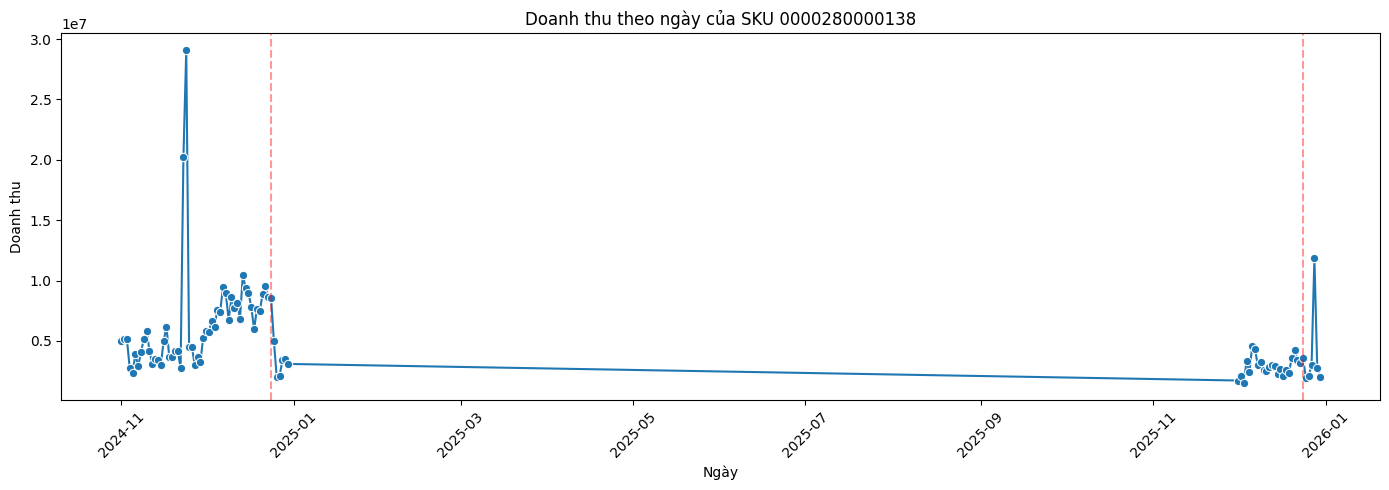

In [28]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=sku_pd, x="date", y="daily_revenue", marker="o")

holiday_dates = sku_pd.loc[sku_pd["is_holiday"] == 1, "date"]
for d in holiday_dates:
    plt.axvline(d, color="red", linestyle="--", alpha=0.4)

plt.title(f"Doanh thu theo ngày của SKU {SKU_ID}")
plt.xlabel("Ngày")
plt.ylabel("Doanh thu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Nhận xét**
- Doanh thu của SKU biến động mạnh giữa các ngày và không duy trì một xu hướng tăng hoặc giảm ổn định trong toàn bộ giai đoạn quan sát.
- Ở giai đoạn 11/2024 - 12/2024, doanh thu nhìn chung cao hơn và xuất hiện một vài đỉnh rất lớn, cho thấy có những ngày bán vượt trội so với mặt bằng chung.
- Ở giai đoạn 12/2025, doanh thu thấp hơn đáng kể so với cuối năm 2024, dù vẫn có một số ngày tăng đột biến.
- Tại hai mốc ngày lễ 24/12/2024 và 24/12/2025, doanh thu không phải là mức cao nhất của chuỗi; điều này gợi ý rằng ảnh hưởng của ngày lễ có thể không nằm đúng vào ngày 24/12 mà xuất hiện ở các ngày lân cận.


#### 3.3. Biểu đồ đường doanh thu quanh các ngày lễ


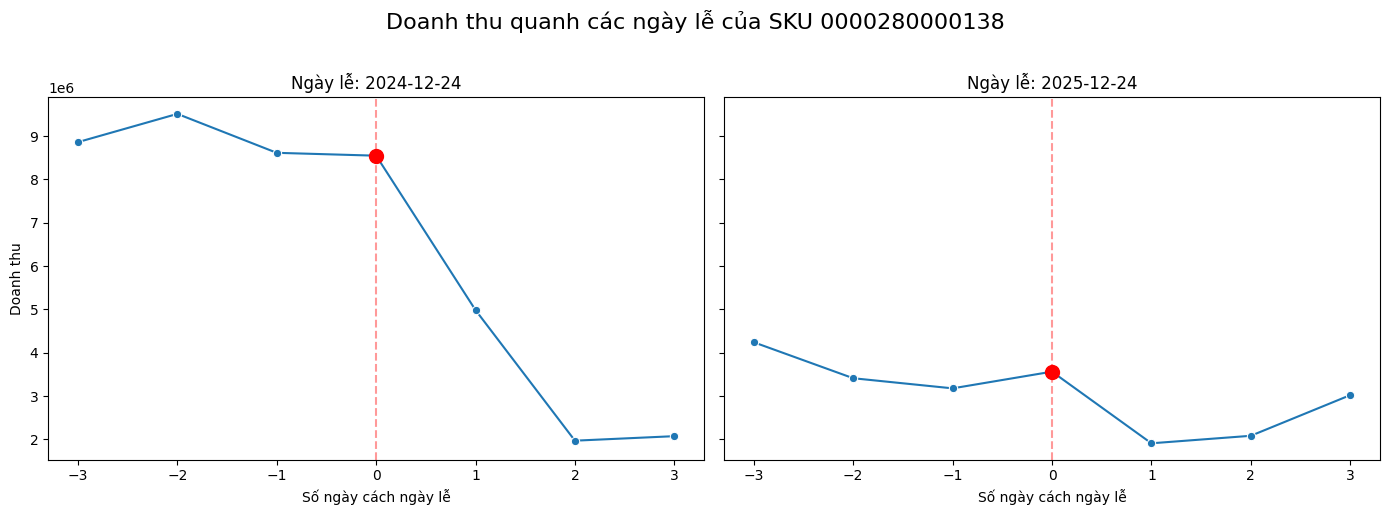

In [29]:
holiday_windows = []
holiday_dates = sorted(sku_pd.loc[sku_pd["is_holiday"] == 1, "date"].unique())

for holiday_date in holiday_dates:
    mask = (sku_pd["date"] >= holiday_date - pd.Timedelta(days=3)) & (sku_pd["date"] <= holiday_date + pd.Timedelta(days=3))
    window_data = sku_pd.loc[mask].copy()
    window_data["days_from_holiday"] = (window_data["date"] - holiday_date).dt.days
    window_data["holiday_focus_date"] = holiday_date
    holiday_windows.append(window_data)

holiday_window_pd = pd.concat(holiday_windows, ignore_index=True)

fig, axes = plt.subplots(1, len(holiday_dates), figsize=(7 * len(holiday_dates), 5), sharey=True)
if len(holiday_dates) == 1:
    axes = [axes]

for ax, holiday_date in zip(axes, holiday_dates):
    plot_data = holiday_window_pd[holiday_window_pd["holiday_focus_date"] == holiday_date].copy()
    sns.lineplot(data=plot_data, x="days_from_holiday", y="daily_revenue", marker="o", ax=ax)
    holiday_point = plot_data[plot_data["days_from_holiday"] == 0]
    ax.scatter(holiday_point["days_from_holiday"], holiday_point["daily_revenue"], color="red", s=100, zorder=3)
    ax.axvline(0, color="red", linestyle="--", alpha=0.4)
    ax.set_title(f"Ngày lễ: {pd.to_datetime(holiday_date).date()}")
    ax.set_xlabel("Số ngày cách ngày lễ")
    ax.set_ylabel("Doanh thu")
    ax.set_xticks(range(-3, 4))

plt.suptitle(f"Doanh thu quanh các ngày lễ của SKU {SKU_ID}", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Nhận xét**
- Ở cả hai năm, doanh thu của SKU đều không đạt đỉnh đúng vào ngày lễ 24/12, mà có xu hướng cao hơn ở một số ngày trước lễ.
- Với 24/12/2024, doanh thu ngày lễ vẫn ở mức cao, nhưng thấp hơn ngày -2 và gần tương đương ngày -1; sau lễ doanh thu giảm rất mạnh trong các ngày +1 đến +3.
- Với 24/12/2025, doanh thu ngày lễ nhỉnh hơn một chút so với hai ngày liền trước, nhưng vẫn thấp hơn mức doanh thu ở ngày -3; sau lễ doanh thu cũng giảm ở ngày +1, rồi phục hồi nhẹ về sau.
- Nhìn chung, biểu đồ gợi ý rằng tác động của holiday nếu có thì thiên về giai đoạn cận lễ, còn sau lễ doanh thu có xu hướng giảm.


#### 3.4. Boxplot và stripplot so sánh ngày lễ với ngày thường


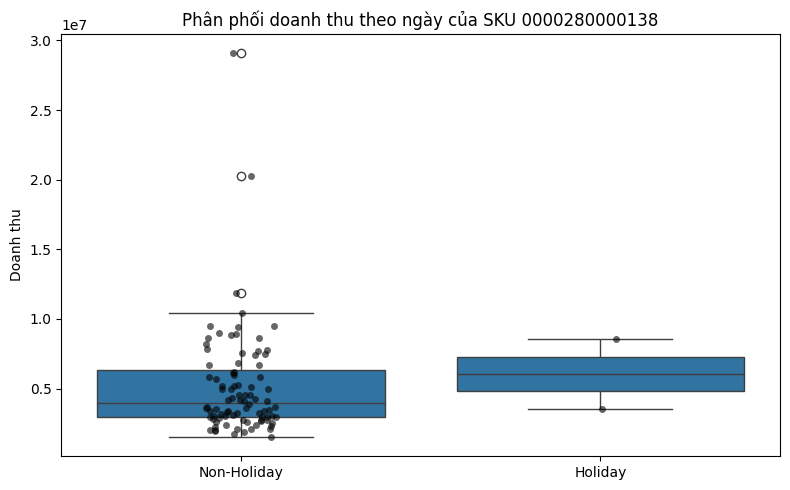

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=sku_pd, x="holiday_label", y="daily_revenue")
sns.stripplot(data=sku_pd, x="holiday_label", y="daily_revenue", color="black", alpha=0.6)
plt.title(f"Phân phối doanh thu theo ngày của SKU {SKU_ID}")
plt.xlabel("")
plt.ylabel("Doanh thu")
plt.tight_layout()
plt.show()

**Nhận xét**
- Nhóm Holiday có mức doanh thu trung vị cao hơn nhóm Non-Holiday, cho thấy doanh thu trong ngày lễ nhìn chung cao hơn ngày thường.
- Phân phối doanh thu của nhóm Non-Holiday phân tán rộng hơn và xuất hiện nhiều điểm ngoại lệ, bao gồm một số ngày doanh thu rất cao.
- Nhóm Holiday có ít quan sát hơn nhiều nên hộp boxplot gọn hơn và mức độ biến động nhìn có vẻ thấp hơn, nhưng điều này cũng có nghĩa là chưa thể kết luận chắc chắn chỉ từ trực quan.
- Nhìn chung, biểu đồ gợi ý rằng ngày lễ có thể đi kèm doanh thu cao hơn mặt bằng ngày thường, nhưng vẫn cần đối chiếu thêm với kiểm định thống kê vì cỡ mẫu ngày lễ rất nhỏ.


### 4. Kiểm định giả thuyết


#### 4.1. Kiểm định ảnh hưởng của ngày lễ đến doanh thu SKU
- H0: Phân phối doanh thu ngày lễ và ngày thường là như nhau
- H1: Hai phân phối khác nhau


In [31]:
holiday_rev = sku_pd.loc[sku_pd["is_holiday"] == 1, "daily_revenue"].astype(float).to_numpy()
nonholiday_rev = sku_pd.loc[sku_pd["is_holiday"] == 0, "daily_revenue"].astype(float).to_numpy()

print("Số ngày lễ:", len(holiday_rev))
print("Số ngày thường:", len(nonholiday_rev))
print("Doanh thu trung bình ngày lễ:", holiday_rev.mean())
print("Doanh thu trung bình ngày thường:", nonholiday_rev.mean())
print("Doanh thu trung vị ngày lễ:", np.median(holiday_rev))
print("Doanh thu trung vị ngày thường:", np.median(nonholiday_rev))

u_stat, p_value = mannwhitneyu(holiday_rev, nonholiday_rev, alternative="two-sided")
print("\nThống kê Mann-Whitney U:", u_stat)
print("Giá trị p của Mann-Whitney:", p_value)

perm_result = permutation_test(
    data=(holiday_rev, nonholiday_rev),
    statistic=lambda x, y: np.mean(x) - np.mean(y),
    permutation_type="independent",
    n_resamples=10000,
    alternative="two-sided",
    random_state=42
)

observed_diff = np.mean(holiday_rev) - np.mean(nonholiday_rev)
print("\nChênh lệch trung bình quan sát được (ngày lễ - ngày thường):", observed_diff)
print("Giá trị p của permutation test:", perm_result.pvalue)

Số ngày lễ: 2
Số ngày thường: 88
Doanh thu trung bình ngày lễ: 6054382.67535
Doanh thu trung bình ngày thường: 5136399.090557954
Doanh thu trung vị ngày lễ: 6054382.67535
Doanh thu trung vị ngày thường: 3988208.6135

Thống kê Mann-Whitney U: 115.0
Giá trị p của Mann-Whitney: 0.49538077403245945

Chênh lệch trung bình quan sát được (ngày lễ - ngày thường): 917983.5847920459
Giá trị p của permutation test: 0.4993757802746567


#### 4.2. Kết luận kiểm định


In [32]:
alpha = 0.05

if p_value < alpha:
    print("Kết luận theo Mann-Whitney: Bác bỏ H0. Có bằng chứng thống kê cho thấy ngày lễ ảnh hưởng đến doanh thu của SKU này.")
else:
    print("Kết luận theo Mann-Whitney: Chưa đủ bằng chứng để bác bỏ H0. Chưa thể kết luận ngày lễ ảnh hưởng đến doanh thu của SKU này.")

if perm_result.pvalue < alpha:
    print("Kết luận theo permutation test: Bác bỏ H0.")
else:
    print("Kết luận theo permutation test: Chưa đủ bằng chứng để bác bỏ H0.")



Kết luận theo Mann-Whitney: Chưa đủ bằng chứng để bác bỏ H0. Chưa thể kết luận ngày lễ ảnh hưởng đến doanh thu của SKU này.
Kết luận theo permutation test: Chưa đủ bằng chứng để bác bỏ H0.
